In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [3]:
web_df1 = pd.read_csv("../data/raw/df_final_web_data_pt_1.txt")
web_df1

,client_id,visitor_id,visit_id,process_step,date_time
0,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:27:07
1,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:26:51
2,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:19:22
3,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:19:13
4,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:18:04
...,...,...,...,...,...
343136,2443347,465784886_73090545671,136329900_10529659391_316129,confirm,2017-03-31 15:15:46
343137,2443347,465784886_73090545671,136329900_10529659391_316129,step_3,2017-03-31 15:14:53
343138,2443347,465784886_73090545671,136329900_10529659391_316129,step_2,2017-03-31 15:12:08
343139,2443347,465784886_73090545671,136329900_10529659391_316129,step_1,2017-03-31 15:11:37


In [4]:
web_df2 = pd.read_csv("../data/raw/df_final_web_data_pt_2.txt")
web_df2

,client_id,visitor_id,visit_id,process_step,date_time
0,763412,601952081_10457207388,397475557_40440946728_419634,confirm,2017-06-06 08:56:00
1,6019349,442094451_91531546617,154620534_35331068705_522317,confirm,2017-06-01 11:59:27
2,6019349,442094451_91531546617,154620534_35331068705_522317,step_3,2017-06-01 11:58:48
3,6019349,442094451_91531546617,154620534_35331068705_522317,step_2,2017-06-01 11:58:08
4,6019349,442094451_91531546617,154620534_35331068705_522317,step_1,2017-06-01 11:57:58
...,...,...,...,...,...
412259,9668240,388766751_9038881013,922267647_3096648104_968866,start,2017-05-24 18:46:10
412260,9668240,388766751_9038881013,922267647_3096648104_968866,start,2017-05-24 18:45:29
412261,9668240,388766751_9038881013,922267647_3096648104_968866,step_1,2017-05-24 18:44:51
412262,9668240,388766751_9038881013,922267647_3096648104_968866,start,2017-05-24 18:44:34


## Data Cleaning


As we can see have two dataframes with the same name columns and they need to be cleaned. The first thing we need to do, since they are, basically,
the same dataframe split in two files is to merge them. From there, we will start the cleaning.

In [5]:
df_web = pd.concat([web_df1, web_df2], axis=0)
df_web = df_web.reset_index(drop=True)
df_web.shape


(755405, 5)

In [6]:
#Check for nulls:
df_web.isnull().sum()

client_id       0
visitor_id      0
visit_id        0
process_step    0
date_time       0
dtype: int64

We are lucky! No nulls, but we can't celebrate yet, since even if it's filled, the data may be inconsistent


In [7]:
df_web.info()

<class 'pandas.DataFrame'>
RangeIndex: 755405 entries, 0 to 755404
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   client_id     755405 non-null  int64
 1   visitor_id    755405 non-null  str  
 2   visit_id      755405 non-null  str  
 3   process_step  755405 non-null  str  
 4   date_time     755405 non-null  str  
dtypes: int64(1), str(4)
memory usage: 28.8 MB


Client id should be an integer, correct, visitor and visit id should be strings as well as process step BUT date should be in date format

In [8]:
df_web['date_time'] = pd.to_datetime(df_web['date_time'])
df_web.info()

<class 'pandas.DataFrame'>
RangeIndex: 755405 entries, 0 to 755404
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   client_id     755405 non-null  int64         
 1   visitor_id    755405 non-null  str           
 2   visit_id      755405 non-null  str           
 3   process_step  755405 non-null  str           
 4   date_time     755405 non-null  datetime64[us]
dtypes: datetime64[us](1), int64(1), str(3)
memory usage: 28.8 MB


In [9]:
df_web.head()


,client_id,visitor_id,visit_id,process_step,date_time
0,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:27:07
1,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:26:51
2,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:19:22
3,9988021,580560515_7732621733,781255054_21935453173_531117,step_2,2017-04-17 15:19:13
4,9988021,580560515_7732621733,781255054_21935453173_531117,step_3,2017-04-17 15:18:04


### Now, we need to keep in mind that our analysis will be to understand the behaviour of the customer. For that we need to sort it chronologically

In [10]:
df_web = df_web.sort_values(by=["client_id", "date_time"])
df_web.head(17)

,client_id,visitor_id,visit_id,process_step,date_time
285515,169,201385055_71273495308,749567106_99161211863_557568,start,2017-04-12 20:19:36
285514,169,201385055_71273495308,749567106_99161211863_557568,step_1,2017-04-12 20:19:45
285513,169,201385055_71273495308,749567106_99161211863_557568,step_2,2017-04-12 20:20:31
285512,169,201385055_71273495308,749567106_99161211863_557568,step_3,2017-04-12 20:22:05
285511,169,201385055_71273495308,749567106_99161211863_557568,confirm,2017-04-12 20:23:09
628456,336,64757908_3400128256,649044751_80905125055_554468,start,2017-06-01 07:26:55
628331,336,64757908_3400128256,649044751_80905125055_554468,start,2017-06-01 07:42:43
442857,546,475037402_89828530214,731811517_9330176838_94847,start,2017-06-17 10:03:29
442856,546,475037402_89828530214,731811517_9330176838_94847,step_1,2017-06-17 10:03:39
442855,546,475037402_89828530214,731811517_9330176838_94847,step_2,2017-06-17 10:03:52


In [11]:
#save web file
df_web.to_csv('df_web.csv', index=False)

## Analyse the client behaviour in the conversion rate from start to confirm:

In [11]:
df_web.groupby("client_id")["process_step"].apply(list).head(20)

client_id
169              [start, step_1, step_2, step_3, confirm]
336                                        [start, start]
546              [start, step_1, step_2, step_3, confirm]
555              [start, step_1, step_2, step_3, confirm]
647              [start, step_1, step_2, step_3, confirm]
722     [start, step_1, step_2, step_1, start, step_1,...
786       [start, start, step_1, step_2, step_3, confirm]
805     [start, step_1, start, step_1, step_2, step_2,...
832     [start, step_1, step_2, step_1, step_2, step_3...
934                          [start, start, start, start]
1028    [start, step_1, step_1, step_2, step_3, step_1...
1039             [start, step_1, step_2, step_3, confirm]
1104                                       [start, start]
1186                       [start, start, step_1, step_2]
1195             [start, step_1, step_2, step_3, confirm]
1197    [start, step_1, step_2, step_3, step_2, step_3...
1281     [start, step_1, step_1, step_2, step_3, confirm]
1336

### There are some irregularities, like starting many times, going upwards and backwards, confirming two times...

In [12]:
# Remove consecutive steps: 
df_web["prev_step"] = df_web.groupby("visit_id")["process_step"].shift()

df_web_clean = df_web[df_web["process_step"] != df_web["prev_step"]]


In [13]:
funnel_df = df_web_clean.pivot_table(
    index=["visit_id", "client_id"],
    columns="process_step",
    values="date_time",
    aggfunc="min"
)

In [14]:
funnel_df["converted"] = funnel_df["confirm"].notna()

### How many people reached the confirm step on average?:

In [15]:
conversion_rate = funnel_df["converted"].mean()
conversion_rate

np.float64(0.5695837236644389)

### 57% of the people, on average, reached the confirm step. These are the average on the diferent step process:

In [16]:
funnel_df.notna().mean()

process_step
confirm      0.569584
start        0.916600
step_1       0.755233
step_2       0.661069
step_3       0.602774
converted    1.000000
dtype: float64

Those analysis are made on the whole population. Not on test/control group, just to get a look at the bigger picture.

More than 8% of the population didn't start on start, which is the "normal" order. That might be because of uncomplete data or that somehow the process could be started in another step via direct access. Though, we think it's important to mention it to help developers.

It's not important for our study questions because here we are yet not incorporing the test and control variation but it give us a hint that this is a pattern that might occur when we classify the database in test and control group.


In [17]:
num_clients = df_web["client_id"].nunique()
print(f"Unique clients: {num_clients}.")

Unique clients: 120157.


# Completion Rate with a Cost-Effectiveness Threshold
Null Hypothesis ($H_0$): The completion rate for the Test group (new design) is equal to or less than the completion rate for the Control group (old design) increased by 5%.
Alternative Hypothesis ($H_a$): The completion rate for the Test group (new design) is greater than the completion rate for the Control group (old design) increased by 5%.
Note: a one-sided two-proportion z-test is appropriate.

Given the new threshold, you will compare the completion rate of the Test group to the completion rate of the Control group increased by 5%.

### 1) download the variation (test/control) table:

In [18]:
import yaml

In [19]:
with open("../config.yaml", "r") as file:
    config = yaml.safe_load(file)

In [20]:
expi_df = pd.read_csv(config["output_data"]["file2"])
expi_df

,client_id,Variation
0,9988021,test
1,8320017,test
2,4033851,control
3,1982004,test
4,9294070,control
...,...,...
50495,393005,control
50496,2908510,control
50497,7230446,test
50498,5230357,test


### 2) Merge it

In [21]:
joined_demo_expi_df = pd.merge(df_web_clean, expi_df, on= 'client_id')
display(joined_demo_expi_df)

,client_id,visitor_id,visit_id,process_step,date_time,prev_step,Variation
0,555,402506806_56087378777,637149525_38041617439_716659,start,2017-04-15 12:57:56,NaN,test
1,555,402506806_56087378777,637149525_38041617439_716659,step_1,2017-04-15 12:58:03,start,test
2,555,402506806_56087378777,637149525_38041617439_716659,step_2,2017-04-15 12:58:35,step_1,test
3,555,402506806_56087378777,637149525_38041617439_716659,step_3,2017-04-15 13:00:14,step_2,test
4,555,402506806_56087378777,637149525_38041617439_716659,confirm,2017-04-15 13:00:34,step_3,test
...,...,...,...,...,...,...,...
284552,9999729,834634258_21862004160,870243567_56915814033_814203,step_2,2017-05-08 16:08:40,step_1,test
284553,9999729,834634258_21862004160,870243567_56915814033_814203,step_3,2017-05-08 16:09:19,step_2,test
284554,9999729,834634258_21862004160,870243567_56915814033_814203,confirm,2017-05-08 16:09:40,step_3,test
284555,9999832,145538019_54444341400,472154369_16714624241_585315,start,2017-05-16 16:46:03,NaN,test


In [22]:
joined_demo_expi_df.to_csv('try_this.csv', index=False)

### Now we got it ordered by client id and time. Both test and control (284557 rows)

In [23]:
df_Hipotesis = joined_demo_expi_df.sort_values(by=["client_id", "date_time",])
display(df_Hipotesis)

,client_id,visitor_id,visit_id,process_step,date_time,prev_step,Variation
0,555,402506806_56087378777,637149525_38041617439_716659,start,2017-04-15 12:57:56,NaN,test
1,555,402506806_56087378777,637149525_38041617439_716659,step_1,2017-04-15 12:58:03,start,test
2,555,402506806_56087378777,637149525_38041617439_716659,step_2,2017-04-15 12:58:35,step_1,test
3,555,402506806_56087378777,637149525_38041617439_716659,step_3,2017-04-15 13:00:14,step_2,test
4,555,402506806_56087378777,637149525_38041617439_716659,confirm,2017-04-15 13:00:34,step_3,test
...,...,...,...,...,...,...,...
284552,9999729,834634258_21862004160,870243567_56915814033_814203,step_2,2017-05-08 16:08:40,step_1,test
284553,9999729,834634258_21862004160,870243567_56915814033_814203,step_3,2017-05-08 16:09:19,step_2,test
284554,9999729,834634258_21862004160,870243567_56915814033_814203,confirm,2017-05-08 16:09:40,step_3,test
284555,9999832,145538019_54444341400,472154369_16714624241_585315,start,2017-05-16 16:46:03,NaN,test


### We make a filter to have only the test (157680 rows)

In [24]:
df_test = df_Hipotesis[df_Hipotesis["Variation"] == "test"]
display(df_test)

,client_id,visitor_id,visit_id,process_step,date_time,prev_step,Variation
0,555,402506806_56087378777,637149525_38041617439_716659,start,2017-04-15 12:57:56,NaN,test
1,555,402506806_56087378777,637149525_38041617439_716659,step_1,2017-04-15 12:58:03,start,test
2,555,402506806_56087378777,637149525_38041617439_716659,step_2,2017-04-15 12:58:35,step_1,test
3,555,402506806_56087378777,637149525_38041617439_716659,step_3,2017-04-15 13:00:14,step_2,test
4,555,402506806_56087378777,637149525_38041617439_716659,confirm,2017-04-15 13:00:34,step_3,test
...,...,...,...,...,...,...,...
284552,9999729,834634258_21862004160,870243567_56915814033_814203,step_2,2017-05-08 16:08:40,step_1,test
284553,9999729,834634258_21862004160,870243567_56915814033_814203,step_3,2017-05-08 16:09:19,step_2,test
284554,9999729,834634258_21862004160,870243567_56915814033_814203,confirm,2017-05-08 16:09:40,step_3,test
284555,9999832,145538019_54444341400,472154369_16714624241_585315,start,2017-05-16 16:46:03,NaN,test


### We make a filter to have only the control (126877 rows)

In [25]:
df_control = df_Hipotesis[df_Hipotesis["Variation"] == "control"]
display(df_control)

,client_id,visitor_id,visit_id,process_step,date_time,prev_step,Variation
11,1028,42237450_62128060588,557292053_87239438319_391157,start,2017-04-08 18:51:28,NaN,control
12,1028,42237450_62128060588,557292053_87239438319_391157,step_1,2017-04-08 18:52:17,start,control
13,1028,42237450_62128060588,557292053_87239438319_391157,step_2,2017-04-08 18:53:29,step_1,control
14,1028,42237450_62128060588,557292053_87239438319_391157,step_3,2017-04-08 18:58:04,step_2,control
15,1028,42237450_62128060588,557292053_87239438319_391157,step_1,2017-04-08 18:59:55,step_3,control
...,...,...,...,...,...,...,...
284509,9998346,292425655_16607136645,189177304_69869411700_783154,step_2,2017-03-29 15:30:11,step_1,control
284510,9998346,292425655_16607136645,189177304_69869411700_783154,step_3,2017-03-29 15:30:25,step_2,control
284511,9998346,292425655_16607136645,189177304_69869411700_783154,confirm,2017-03-29 15:37:28,step_3,control
284512,9998346,292425655_16607136645,189177304_69869411700_783154,step_3,2017-03-29 15:37:28,confirm,control


### Next step is to get the completion rates for test and control. We start with test


In [26]:
completion_rate_test = df_test[df_test["process_step"] == "confirm"]["client_id"].nunique() / df_test["client_id"].nunique()

print(f"Completion rate test: {completion_rate_test:.2%}")

Completion rate test: 69.29%


### Now with Control:

In [27]:
completion_rate_control = df_control[df_control["process_step"] == "confirm"]["client_id"].nunique() / df_control["client_id"].nunique()

print(f"Completion rate control: {completion_rate_control:.2%}")

Completion rate control: 65.58%


### Two proportion Z-test:

To evaluate our hipothesis, which is that the test group has to be over the threshold of 5% better, we will execute a two proportion test
it's the most apropiate test when you are comparing ratios. In this case we are comparing the ratio of completion for both variations. 

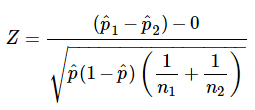

In [28]:
Clients_that_compleated_test = df_test[df_test["process_step"] == "confirm"]["client_id"].nunique()
Clients_that_compleated_test


18686

In [29]:
Clients_that_compleated_control = df_control[df_control["process_step"] == "confirm"]["client_id"].nunique()
Clients_that_compleated_control

15432

In [30]:
Total_number_of_test = df_test["client_id"].nunique()
Total_number_of_test

26966

In [31]:
Total_number_of_control = df_control["client_id"].nunique()
Total_number_of_control

23530

In [32]:
p = (Clients_that_compleated_test + Clients_that_compleated_control)/(Total_number_of_test + Total_number_of_control)
p

0.6756574778200254

In [33]:
import math

In [36]:
 
Z_completion = ((completion_rate_test)-(completion_rate_control)-0.05)/(math.sqrt(p*(1-p)*((1/Total_number_of_test)+(1/Total_number_of_control))))
print(Z_completion)

# H0: test_ratio >= control_ratio + 0.05 # the desired difference
# Ha: test_ratio < control_ratio + 0.05

# H0: test_ratio - control_ratio >= 0.05 (delta = 0.05)
# Ha: control_ration - test_ratio < 0

import scipy.stats as st

# Computing the critical values; total rejection area = alpha = 0.05

critical_value = st.norm.ppf(0.05)

print(f"The lower critical value is: {critical_value:.2f}")

p_value = st.norm.cdf(Z_completion)
print(f"The p-value is: {p_value:.4f}")


-3.0882457676854536
The lower critical value is: -1.64
The p-value is: 0.0010


Z-Score = -3.088 < -1.64, we reject the null Hypothesis. Which means we are NOT accomplishing the 5% demanded threshold on the completion ratio. 

### But there might be a bottleneck, let's do that for every step. In order to do that efficiently, lets first summarize all we did in a defined function:


In [37]:
def two_proportion_z_test(df_test, df_control, step, threshold=0.05):
    
    completed_test = df_test[df_test["process_step"] == step]["client_id"].nunique()
    completed_control = df_control[df_control["process_step"] == step]["client_id"].nunique()
    
    total_test = df_test["client_id"].nunique()
    total_control = df_control["client_id"].nunique()
    
    rate_test = completed_test / total_test
    rate_control = completed_control / total_control
    
    p_pool = (completed_test + completed_control) / (total_test + total_control)
    
    z = (rate_test - rate_control - threshold) / (math.sqrt(p_pool * (1 - p_pool) * ((1 / total_test) + (1 / total_control))))
    
    critical_value = st.norm.ppf(0.05)
    p_value = st.norm.cdf(z)
    
    print(f"Step: {step}")
    print(f"Rate test: {rate_test:.2%} | Rate control: {rate_control:.2%} | Difference: {rate_test - rate_control:.2%}")
    print(f"Z-score: {z:.4f} | Critical value: {critical_value:.2f} | P-value: {p_value:.4f}")
    
    if z < critical_value:
        print("Reject H0 → the improvement does NOT reach the threshold\n")
    else:
        print("Accept Ha → the improvement reaches the threshold\n")

In [38]:
for step in ["start", "step_1", "step_2", "step_3", "confirm"]:
    two_proportion_z_test(df_test, df_control, step)

Step: start
Rate test: 98.92% | Rate control: 99.41% | Difference: -0.48%
Z-score: -66.8269 | Critical value: -1.64 | P-value: 0.0000
Reject H0 → the improvement does NOT reach the threshold

Step: step_1
Rate test: 89.99% | Rate control: 85.64% | Difference: 4.35%
Z-score: -2.2489 | Critical value: -1.64 | P-value: 0.0123
Reject H0 → the improvement does NOT reach the threshold

Step: step_2
Rate test: 82.54% | Rate control: 79.26% | Difference: 3.28%
Z-score: -4.9146 | Critical value: -1.64 | P-value: 0.0000
Reject H0 → the improvement does NOT reach the threshold

Step: step_3
Rate test: 77.43% | Rate control: 74.04% | Difference: 3.39%
Z-score: -4.2094 | Critical value: -1.64 | P-value: 0.0000
Reject H0 → the improvement does NOT reach the threshold

Step: confirm
Rate test: 69.29% | Rate control: 65.58% | Difference: 3.71%
Z-score: -3.0882 | Critical value: -1.64 | P-value: 0.0010
Reject H0 → the improvement does NOT reach the threshold



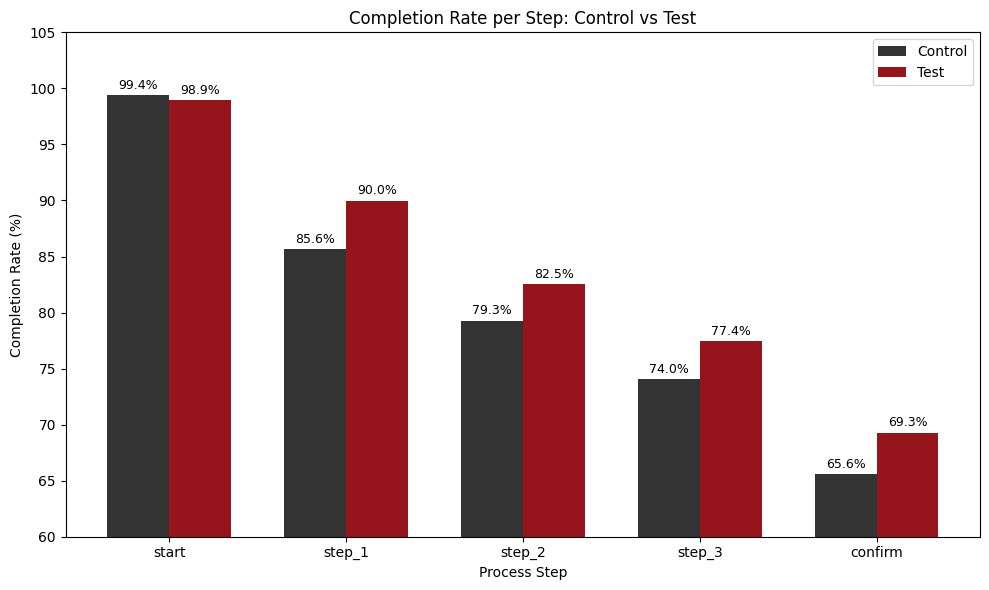

In [50]:
steps = ["start", "step_1", "step_2", "step_3", "confirm"]

rates_control = [99.41, 85.64, 79.26, 74.04, 65.58]
rates_test    = [98.92, 89.99, 82.54, 77.43, 69.29]

x = np.arange(len(steps))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

bars_control = ax.bar(x - width/2, rates_control, width, label="Control", color="#333333")
bars_test    = ax.bar(x + width/2, rates_test,    width, label="Test",    color="#96151D")


for bar in bars_control:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{bar.get_height():.1f}%", ha="center", va="bottom", fontsize=9)

for bar in bars_test:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{bar.get_height():.1f}%", ha="center", va="bottom", fontsize=9)

ax.set_xlabel("Process Step")
ax.set_ylabel("Completion Rate (%)")
ax.set_title("Completion Rate per Step: Control vs Test")
ax.set_xticks(x)
ax.set_xticklabels(steps)
ax.set_ylim(60, 105)
ax.legend()

plt.tight_layout()
plt.show()

### The new test version shows improvements in every step, but doesn't reach the minimum 5% threshold required (Though is pretty close in step 1)
### Its VERY IMPORTANT to note that these improvements didn't happen by chance, that's why we did the Z test. 
### In one step they might be over 5% (which is not the case), but also, if that was the case, it would have need to pass the Z-test aswell


## Conclusion: The new UI design does NOT meet the requirements to be cost-effective. 

# Time Spent on Each Step

Now, we will analyse the time difference between each step for each visit

Before, we sorted the dataframe by time and client, now is when this will become useful.

In [51]:
df_Hipotesis.head(15)

,client_id,visitor_id,visit_id,process_step,date_time,prev_step,Variation,time_diff,time_diff_seconds,next_step,interval_duration,transition
0,555,402506806_56087378777,637149525_38041617439_716659,start,2017-04-15 12:57:56,NaN,test,NaT,NaN,step_1,7.0,start -> step_1
1,555,402506806_56087378777,637149525_38041617439_716659,step_1,2017-04-15 12:58:03,start,test,0 days 00:00:07,7.0,step_2,32.0,step_1 -> step_2
2,555,402506806_56087378777,637149525_38041617439_716659,step_2,2017-04-15 12:58:35,step_1,test,0 days 00:00:32,32.0,step_3,99.0,step_2 -> step_3
3,555,402506806_56087378777,637149525_38041617439_716659,step_3,2017-04-15 13:00:14,step_2,test,0 days 00:01:39,99.0,confirm,20.0,step_3 -> confirm
4,555,402506806_56087378777,637149525_38041617439_716659,confirm,2017-04-15 13:00:34,step_3,test,0 days 00:00:20,20.0,NaN,NaN,NaN
5,647,66758770_53988066587,40369564_40101682850_311847,start,2017-04-12 15:41:28,NaN,test,NaT,NaN,step_1,7.0,start -> step_1
6,647,66758770_53988066587,40369564_40101682850_311847,step_1,2017-04-12 15:41:35,start,test,0 days 00:00:07,7.0,step_2,18.0,step_1 -> step_2
7,647,66758770_53988066587,40369564_40101682850_311847,step_2,2017-04-12 15:41:53,step_1,test,0 days 00:00:18,18.0,step_3,189.0,step_2 -> step_3
8,647,66758770_53988066587,40369564_40101682850_311847,step_3,2017-04-12 15:45:02,step_2,test,0 days 00:03:09,189.0,confirm,163.0,step_3 -> confirm
9,647,66758770_53988066587,40369564_40101682850_311847,confirm,2017-04-12 15:47:45,step_3,test,0 days 00:02:43,163.0,NaN,NaN,NaN


As you can see it includes both variations, test and control and is sorted by date_time and process_step for every single client


1st, we are going to calculate the difference of time between steps for every client's visit:

In [52]:
df_Hipotesis["time_diff"] = df_Hipotesis.groupby(["client_id", "visit_id"])["date_time"].diff()


Lets check the client 555, that we have a little bit above and see what happened:

In [53]:
client_555 = df_Hipotesis[df_Hipotesis['client_id'] == 555]
client_555

,client_id,visitor_id,visit_id,process_step,date_time,prev_step,Variation,time_diff,time_diff_seconds,next_step,interval_duration,transition
0,555,402506806_56087378777,637149525_38041617439_716659,start,2017-04-15 12:57:56,NaN,test,NaT,NaN,step_1,7.0,start -> step_1
1,555,402506806_56087378777,637149525_38041617439_716659,step_1,2017-04-15 12:58:03,start,test,0 days 00:00:07,7.0,step_2,32.0,step_1 -> step_2
2,555,402506806_56087378777,637149525_38041617439_716659,step_2,2017-04-15 12:58:35,step_1,test,0 days 00:00:32,32.0,step_3,99.0,step_2 -> step_3
3,555,402506806_56087378777,637149525_38041617439_716659,step_3,2017-04-15 13:00:14,step_2,test,0 days 00:01:39,99.0,confirm,20.0,step_3 -> confirm
4,555,402506806_56087378777,637149525_38041617439_716659,confirm,2017-04-15 13:00:34,step_3,test,0 days 00:00:20,20.0,NaN,NaN,NaN


It worked, but 0 days is gonna be unuseful when calculating aggregatinon functions later, lets clean it up to seconds:

In [54]:
df_Hipotesis['time_diff_seconds'] = df_Hipotesis['time_diff'].dt.total_seconds()

In [55]:
client_555 = df_Hipotesis[df_Hipotesis['client_id'] == 555]
client_555

,client_id,visitor_id,visit_id,process_step,date_time,prev_step,Variation,time_diff,time_diff_seconds,next_step,interval_duration,transition
0,555,402506806_56087378777,637149525_38041617439_716659,start,2017-04-15 12:57:56,NaN,test,NaT,NaN,step_1,7.0,start -> step_1
1,555,402506806_56087378777,637149525_38041617439_716659,step_1,2017-04-15 12:58:03,start,test,0 days 00:00:07,7.0,step_2,32.0,step_1 -> step_2
2,555,402506806_56087378777,637149525_38041617439_716659,step_2,2017-04-15 12:58:35,step_1,test,0 days 00:00:32,32.0,step_3,99.0,step_2 -> step_3
3,555,402506806_56087378777,637149525_38041617439_716659,step_3,2017-04-15 13:00:14,step_2,test,0 days 00:01:39,99.0,confirm,20.0,step_3 -> confirm
4,555,402506806_56087378777,637149525_38041617439_716659,confirm,2017-04-15 13:00:34,step_3,test,0 days 00:00:20,20.0,NaN,NaN,NaN


A new column named time_diff_seconds has been created at the end

Now we can do aggregation measures to compare both variations; test and control. We will use the mean and the median and make a comparisson
as we know, the mean is heavily affected by outliers, which in our case might be situations like a power down, an emergency or a coffee break

In order to see bottlenecks or great upgrades we need to analyze it from one step to the next one. In order to do that we will:

In [56]:
# 1) Create the column next step
df_Hipotesis["next_step"] = df_Hipotesis.groupby(["client_id", "visit_id"])["process_step"].shift(-1)

# 2) Calculate the duration until the next step
df_Hipotesis["interval_duration"] = df_Hipotesis.groupby(["client_id", "visit_id"])["date_time"].diff(-1).dt.total_seconds().abs()

# 3) Define the name of the interval
df_Hipotesis["transition"] = df_Hipotesis["process_step"] + " -> " + df_Hipotesis["next_step"]

# 4) Filter out only the logical steps, this is VERY important in order to discard something strange
steps_good = ["start -> step_1", "step_1 -> step_2", "step_2 -> step_3", "step_3 -> confirm"]
df_transicions = df_Hipotesis[df_Hipotesis["transition"].isin(steps_good)]

# 5) Finally Group by mean and median
final_result = df_transicions.groupby(["Variation", "transition"])["interval_duration"].agg(["mean", "median"]).unstack(level=0)

display(final_result)

mean              median      
Variation             control        test control  test
transition                                             
start -> step_1     65.058278   60.743643    20.0  12.0
step_1 -> step_2    36.022571   41.308755    19.0  25.0
step_2 -> step_3    90.216398   88.423423    68.0  66.0
step_3 -> confirm  134.363583  110.439610    78.0  53.0

Key Insights for the Business Case
1) Reduced Initial Friction
The Test group moves from the landing page (start) to the first step 40% faster than the Control group. This suggests that the new UI has a much clearer "Call to Action" (CTA) and better initial guidance.

2) The Step 1 Bottleneck
Interestingly, the transition from step_1 to step_2 is slower in the Test group (25s vs 19s).

Hypothesis: The new design for Step 1 might be more complex, require more data input, or include additional information that slows the user down. This is a specific area for the design team to review.

3) High-Impact Closing Efficiency
The most critical finding is the 25-second reduction in the final transition (step_3 to confirm). In fintech, the final confirmation is where most "drop-offs" occur due to second-guessing. A faster, more fluid final step directly correlates with a higher Completion Rate.

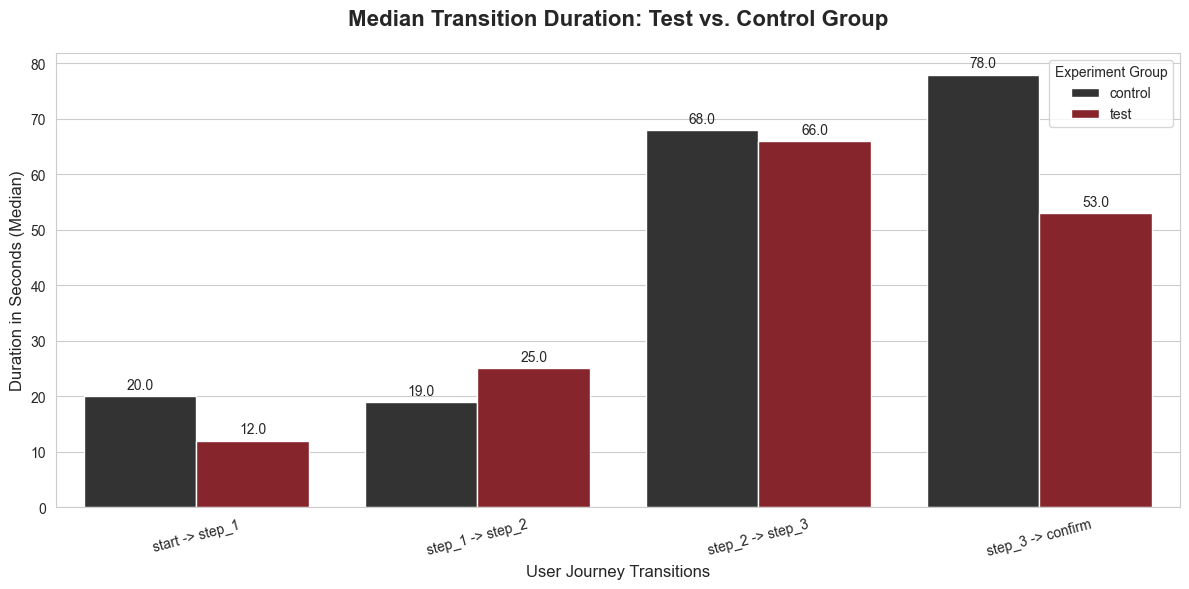

In [57]:
import seaborn as sns
plot_data = final_result["median"].reset_index().melt(id_vars="transition", var_name="Variation", value_name="median_seconds")

plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")


company_colors = {"control":"#333333" , "test": "#96151D"}

ax = sns.barplot(
    data=plot_data, 
    x="transition", 
    y="median_seconds", 
    hue="Variation", 
    palette=company_colors
)

plt.title("Median Transition Duration: Test vs. Control Group", fontsize=16, fontweight="bold", pad=20)
plt.xlabel("User Journey Transitions", fontsize=12)
plt.ylabel("Duration in Seconds (Median)", fontsize=12)
plt.xticks(rotation=15)
plt.legend(title="Experiment Group")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", padding=3)

plt.tight_layout()
plt.show()

 Overall, the New Design (Test) is much faster at the beginning and the very end of the process. Even though Step 1 is a bit slower, saving 25 seconds at the final confirmation is a huge success for the user experience.

### But, that is not enough, we hace to remember that we are working with samples. To be accurate we need to perform a statistical test.
### For that, we will need the mean, not the median, but lets see what happens with the mean:

The slowest user took: 699.28 minutes


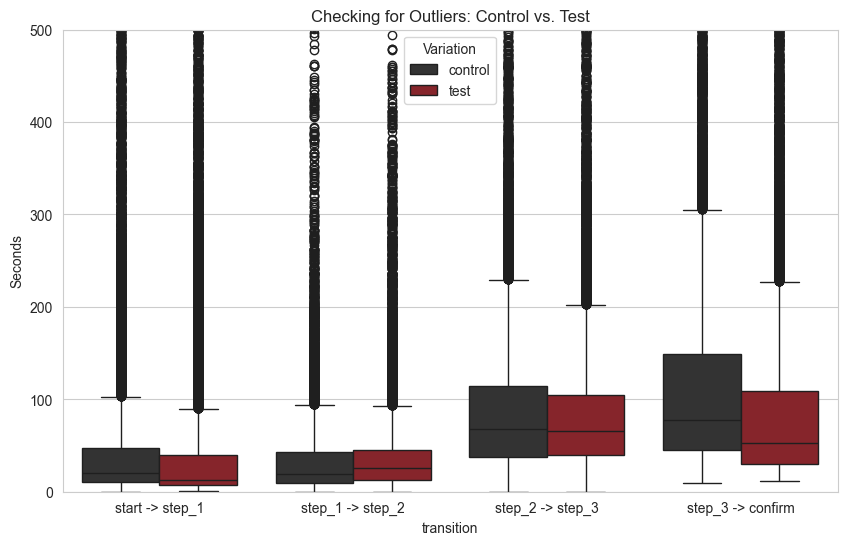

In [58]:
max_time = df_transicions["interval_duration"].max()
print(f"The slowest user took: {max_time / 60:.2f} minutes")

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

sns.boxplot(
    data=df_transicions, 
    x="transition", 
    y="interval_duration", 
    hue="Variation", 
    hue_order=["control", "test"],
    palette={"control":"#333333" , "test":"#96151D" }
)

plt.title("Checking for Outliers: Control vs. Test")
plt.ylabel("Seconds")
plt.ylim(0, 500) # limit to 500 or else we wont be able see it properly
plt.show()

As we can see this is a heavyly skewed distribution. Let's "cap" the values to have something closer to the mean


We can cap the start->step_1 at 120, the 1-2 at 90, the 2-3 at 240 and the 3-confirm at 320

In [59]:
# 1 Create a dictonary for the limits

limits = {
    "start -> step_1": 120,
    "step_1 -> step_2": 90,
    "step_2 -> step_3": 240,
    "step_3 -> confirm": 320
}

# 2 Apply a filter for every step

df_filtered = df_transicions[
    df_transicions.apply(lambda x: x["interval_duration"] <= limits.get(x["transition"], 999999), axis=1)
]

# 3. Recalculate the clean results

final_clean = df_filtered.groupby(["Variation", "transition"])["interval_duration"].agg(["mean", "median"]).unstack(level=0)

display(final_clean)

mean             median      
Variation            control       test control  test
transition                                           
start -> step_1    26.491910  21.021239    17.0  11.0
step_1 -> step_2   24.526321  27.902545    17.0  22.0
step_2 -> step_3   75.195917  74.249838    64.0  64.0
step_3 -> confirm  92.328636  72.738222    71.0  49.0

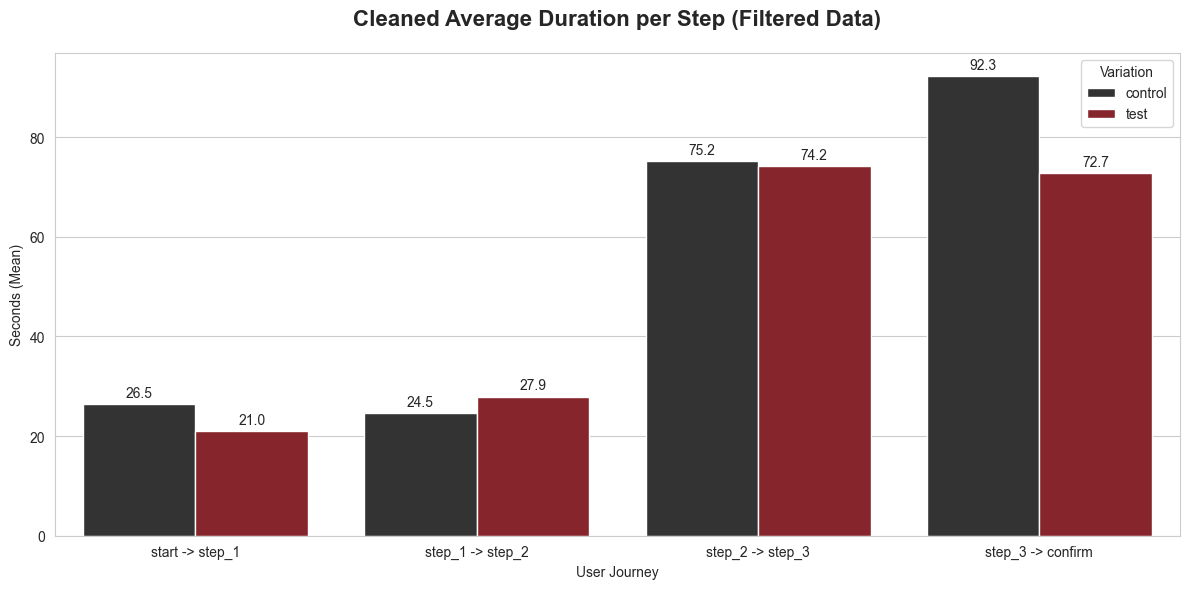

In [60]:
plot_final = final_clean["mean"].reset_index().melt(id_vars="transition", var_name="Variation", value_name="mean_seconds")

plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")


company_colors = {"control":"#333333" , "test": "#96151D"}

ax = sns.barplot(
    data=plot_final, 
    x="transition", 
    y="mean_seconds", 
    hue="Variation", 
    hue_order=["control", "test"],
    palette=company_colors
)

plt.title("Cleaned Average Duration per Step (Filtered Data)", fontsize=16, fontweight="bold", pad=20)
plt.ylabel("Seconds (Mean)")
plt.xlabel("User Journey")


for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", padding=3)

plt.tight_layout()
plt.show()

Now that we have the data less noisy we can do a statistical test to see if this results happened by chance or they are accurate
It's important to note that we do it now because without the "cleaning" the std would have been huge and the result would have been: no significant differences.

First, we define our hypothesis:
H0: There are no significant differences in time between Control and Test
Ha: There are significant differences (One is faster or slower than the other)

If the p-Value <0.05 we reject the null hypothesis (So there are significant differences)
On the other hand, when looking at the T-Statistic, there is no common limit but it use to be arround +/- 2 (we will see that in our case are gigantic)

In [61]:
ttest_results = []

# Iterate for every unique transaction
for trans in df_filtered["transition"].unique():
    # Filter the times for each group
    group_control = df_filtered[(df_filtered["transition"] == trans) & (df_filtered["Variation"] == "control")]["interval_duration"]
    group_test = df_filtered[(df_filtered["transition"] == trans) & (df_filtered["Variation"] == "test")]["interval_duration"]
    
    # Execute the 2 Sample T-test (we use equal_var=False to deal with the unequal variances)
    t_stat, p_val = st.ttest_ind(group_control, group_test, equal_var=False)
    
   
    ttest_results.append({
        "Transition": trans,
        "T-Statistic": round(t_stat, 4),
        "P-Value": round(p_val, 4), # Ponemos muchos decimales por si es muy pequeño
        "Significant?": "Yes" if p_val < 0.05 else "No"
    })

# Transform it into a dataframe
df_ttest = pd.DataFrame(ttest_results)
display(df_ttest)

,Transition,T-Statistic,P-Value,Significant?
0,start -> step_1,25.5676,0.0000,Yes
1,step_1 -> step_2,-17.6102,0.0000,Yes
2,step_2 -> step_3,1.9423,0.0521,No
3,step_3 -> confirm,26.3495,0.0000,Yes


# Conclusions

**We found a Bottleneck:** Our T-Test confirms that Step 1 is slower in the new design (T = -17.6). Even though the whole process is faster, we should tell them to check Step 1, because users are getting a bit stuck there.

**Statistically Proven Success:** The time saved in the final step (confirm) is not a coincidence. With a P-Value of 0.0, we can guarantee that the new design helps users finish their investment much faster.

**No change in Step 2:** In the transition to Step 3, the difference was so small that the test said "No Significant" (P = 0.052). It means both versions are basically doing the same job here, we can see it in the median graph aswell, the values are so close.